#House Price Prediction using Machine Learning

### Problem Statement

Q. Real estate market me house prices predict karna ek important problem hai.
   Is project ka goal hai ki different features (jaise area, year built, condition, basement area, etc.) ke basis par house price (SalePrice) predict kiya ja sake using Machine Learning models.

## Import Libraries

In [25]:
import pandas as pd 
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

### Data Loading

In [26]:
df = pd.read_csv('HousePricePrediction.csv')
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


### EDA

In [27]:
df['Exterior1st'].value_counts()

Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: count, dtype: int64

In [28]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [29]:
df = df.dropna()

# 1459 missing values of saleprice will reproduce lot of variarmtions in preice prediction removed all null values

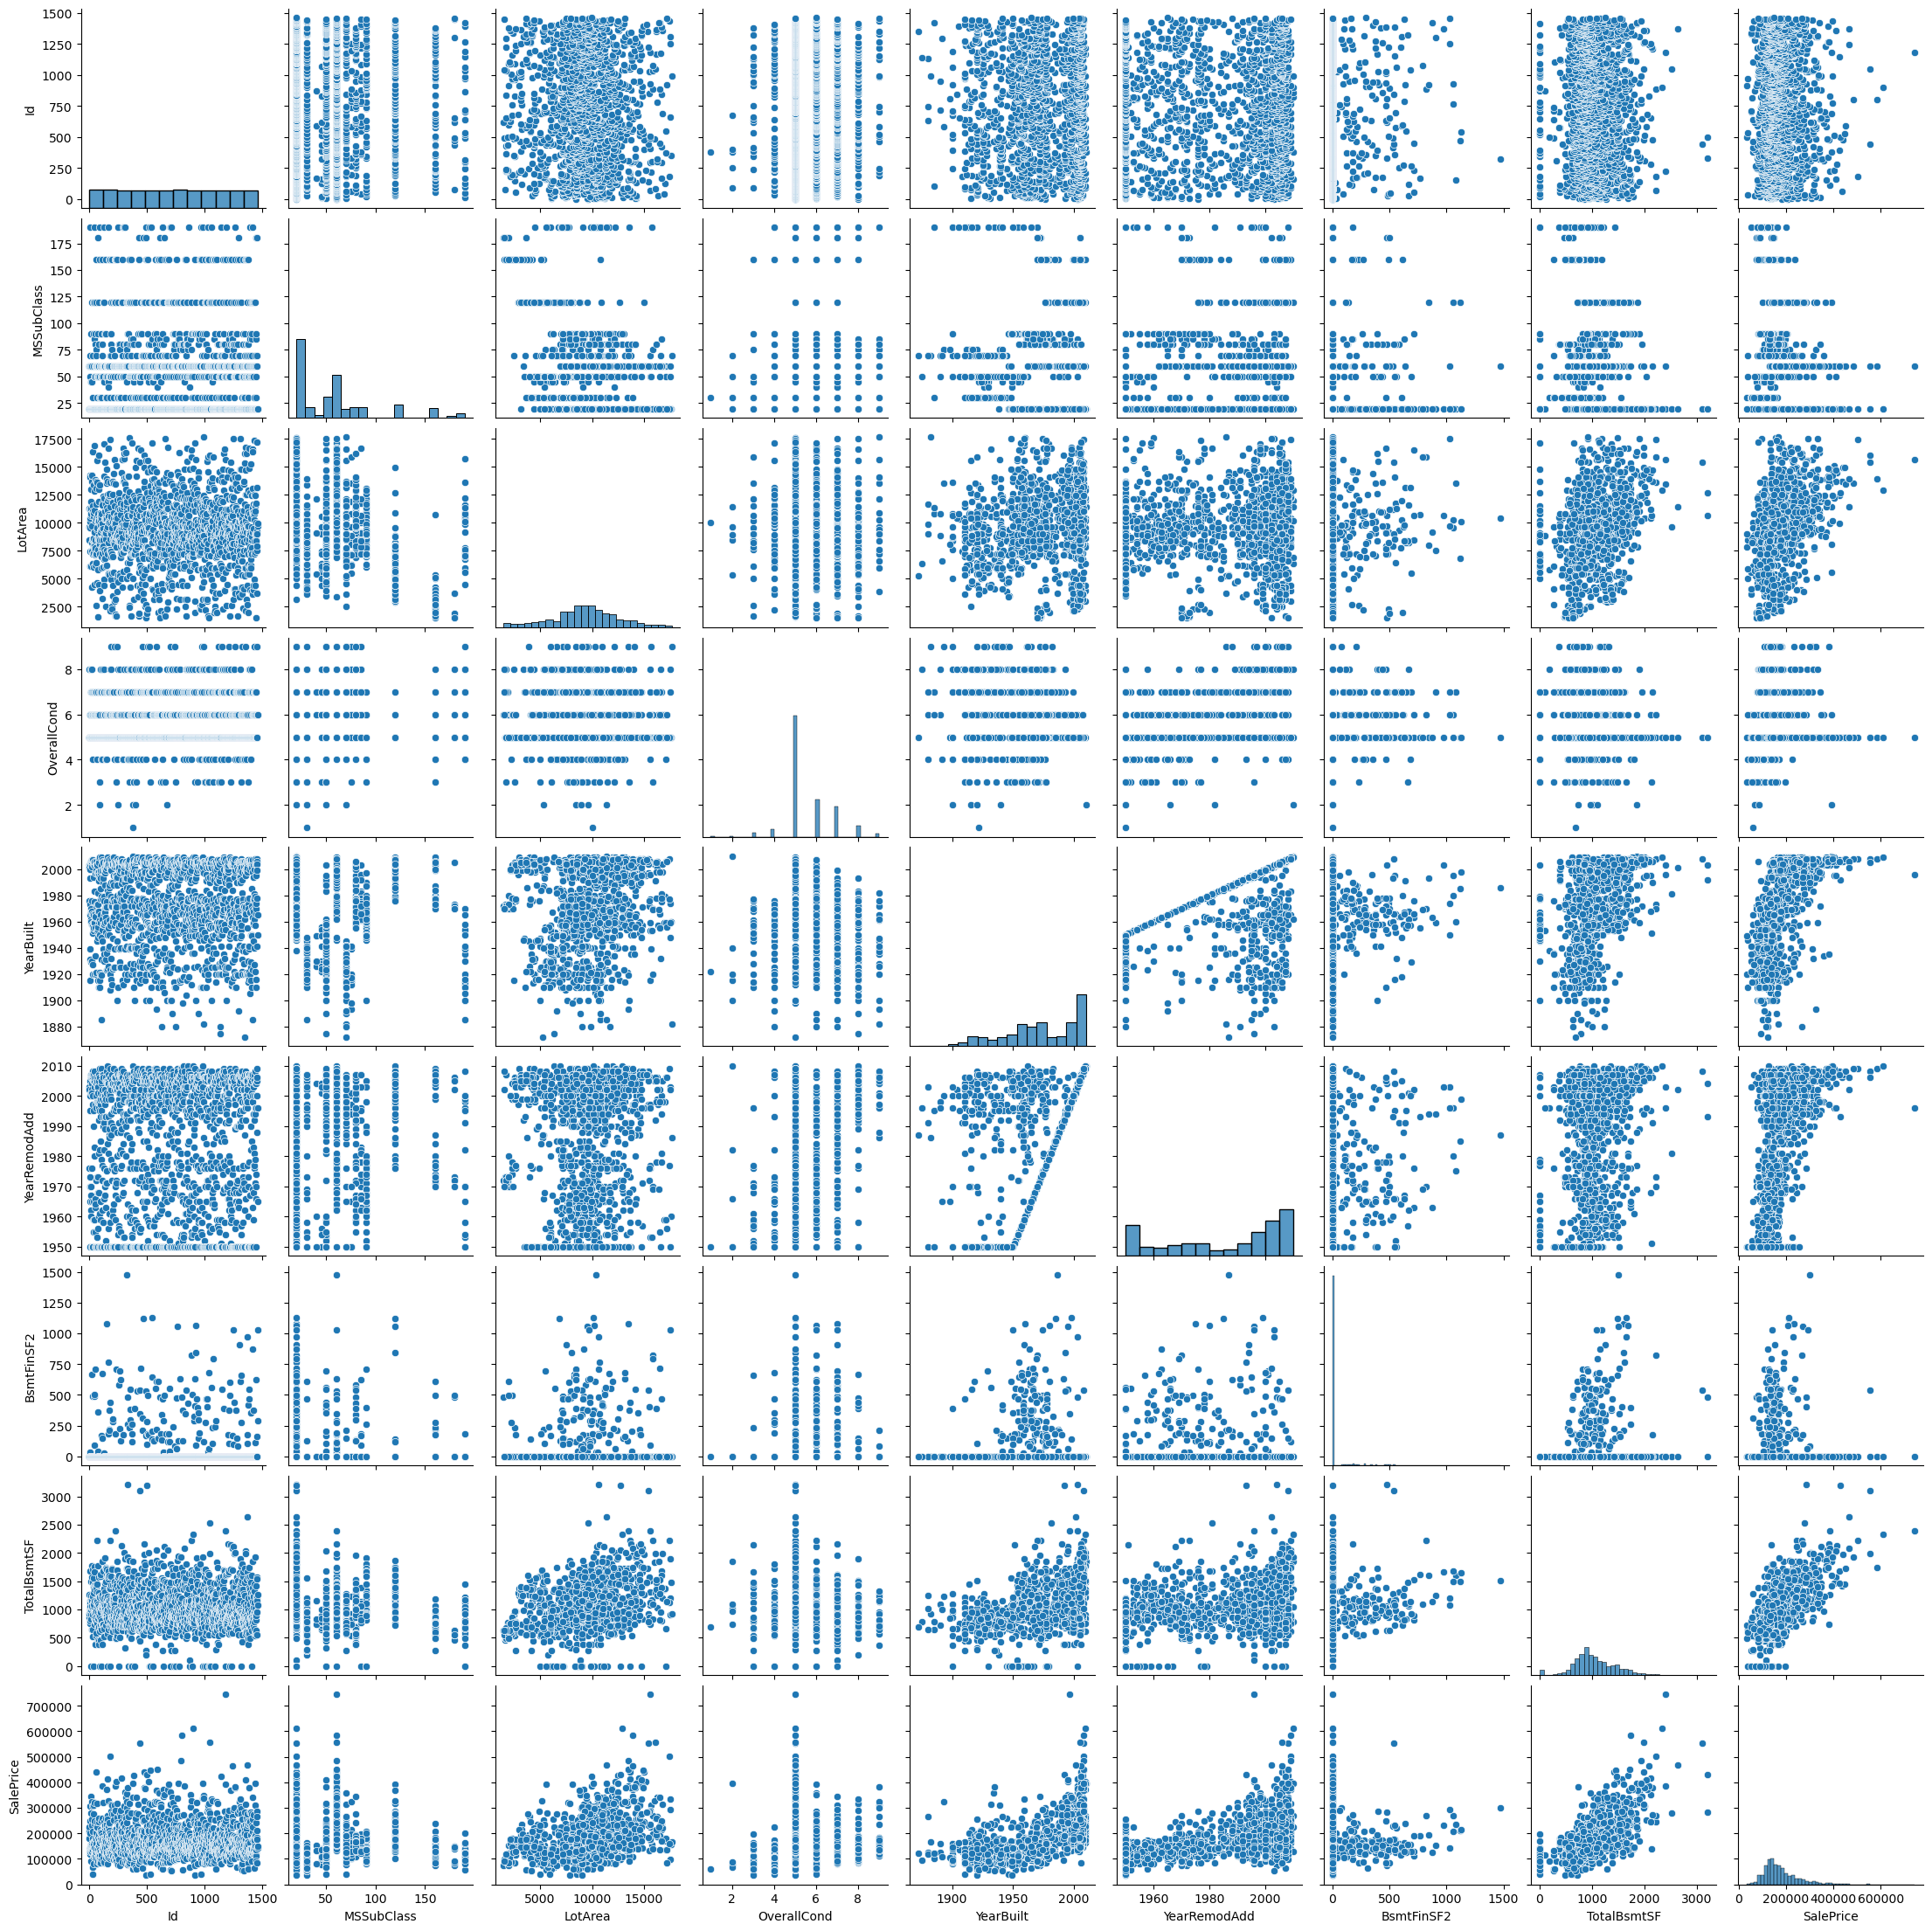

In [18]:
sns.pairplot(df)

### Outlier Removal

In [30]:
Q1 = df['LotArea'].quantile(0.25)
Q3 = df['LotArea'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['LotArea'] >= lower_bound) & (df['LotArea'] <= upper_bound)]

#### Feature Enginnering

In [31]:
df.loc[:, 'age_of_house'] = 2026 - df['YearRemodAdd']

In [32]:
df = df.drop(['YearBuilt','YearRemodAdd','Id'], axis=1)

### OneHot Encoding

In [36]:
df = pd.get_dummies(df, drop_first=True)

### train-test split

In [52]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling

In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Model

In [54]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

### Evaluation

In [55]:
print("r2_score:", r2_score(y_test, y_pred))
print("mean_squared_error:", mean_squared_error(y_test, y_pred))

r2_score: 0.6606090855427527
mean_squared_error: 1971212169.3833108


# Regularisation

## L1

In [57]:
model = Lasso()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("r2_score:", r2_score(y_test, y_pred))
print("mean_squared_error:", mean_squared_error(y_test, y_pred))

r2_score: 0.6605981594040226
mean_squared_error: 1971275629.3544288


## L2

In [58]:
model = Ridge()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("r2_score:", r2_score(y_test, y_pred))
print("mean_squared_error:", mean_squared_error(y_test, y_pred))

r2_score: 0.6606200307329295
mean_squared_error: 1971148598.7597206
